# Lab 3: Sentinel-1 Time Series for Crop Growth in Midwest Row-Crop Fields

This notebook is for a lab on seasonal crop growth using Sentinel-1 SAR backscatter in large Midwestern U.S. fields.

The lab is designed to stay fully in Google Earth Engine + Python. We will be:

- building a consistent Sentinel-1 time series,
- selecting individual row-crop fields, forested regions, and towns/cities,
- extracting field-scale backscatter statistics,
- comparing seasonal trajectories,
- proposing a simple crop growth metric based on VV, VH, or VV/VH.

---

## Lab concept

Students will:

1. choose several individual regions in a Midwest US AOI. You do not have to choose a midwest US AOI, but it will be the easiest. Midwest US/Canada has perfectly North/South Aligned farms in 1.5 km grids, which uniformly grow corn/wheat/soy/etc. European farms are much smaller, and randomly oriented. Averaging over an entire field will increase the signal to noise ratio.
2. define field polygons as regions of interest,
3. build a seasonal Sentinel-1 time series,
4. compute field-level summary statistics for:
   - VV
   - VH
   - VV - VH (in dB is a convenient proxy related to VV/VH ratio)
5. interpret how those quantities evolve from:
   - bare ground / early season
   - vegetative growth
   - maturity
   - senescence (interesting fact - senescence progression is monitored via NDVI)
   - harvest

---

## Why the Midwest U.S.?

This is a good teaching region because many fields are:

- large,
- homogeneous,
- easy to outline,
- minimally affected by complex topography,
- dominated by row crops with strong seasonal structure.

That makes field-scale SAR time series much easier to interpret than small, irregular fields. Irregularly oriented fields produce an additional complexity with regards to geometry. You may have noticed when exploring Krakow SAR that the backscatter from farms could vary greatly. This can be due to differences in crop type, but it can also be related to how the rows are oriented with respect to the satellite look direction. Think about the ground texture of farms, there are many small ridges and valleys. If these ridges and valleys are parallel to the satellite look direction, backscatter will be weaker, and if the ridges and valleys are perpendicular to the satellite look direction, backscatter will be stronger.

---

## learning goals

By the end of this lab, students should be able to:

- explain why SAR time series must be filtered consistently,
- compute a field-averaged VV and VH time series,
- compare crop fields with a non-crop control,
- propose and defend simple crop growth metrics,
- explain why VH or VV-VH may respond differently from VV alone.

---

## 1. Imports and Earth Engine initialization

This notebook assumes that students already have:

- a working Python environment,
- the Earth Engine Python API,
- `geemap`,
- libraries `matplotlib` and `pandas`.

In [2]:
import ee
import geemap
import pandas as pd
import json
import matplotlib.pyplot as plt

PROJECT_ID = "gee-lab1-494721"

try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

print("Earth Engine initialized.")

Earth Engine initialized.


## 2. Define an agricultural AOI

This notebook starts with a large AOI in northern Iowa / southern Minnesota.  
You can adjust it later, but it is helpful to begin with a region dominated by large row-crop fields. In one scene, I want you to find a place that has:

- individual crop fields that you can isolate
- A city or town that we're not expecting a strong vegetative growth signal from
- a stand of trees you can isolate

**QUESTION (5pts): Why is the subregion you chose a good choice for exploring crop growth? Trees and crops both have vegetative growth during summer months, but what differences would you expect to see over a year, with regards to VV, VH, and VV-VH? What do you expect to see in the city or town that you have isolated?**

**ANSWER:** 
Crops have varying coverage throughout the year, which causes their height to change. Crops undergo significant structural changes throughout the year, from bare soil to dense vegetation and then harvest. They will show low VV and VH outside the growing season due to smooth soil surfaces, while during the growing season both VV and especially VH increase due to volume scattering from vegetation. As a result, VV–VH will also vary significantly over time. 

Trees change vegetation throughout the year, but their height remains constant. Outside the growing season, trees will have high signal scattering due to their treetops, which remain unchanged regardless of the season and will effectively scatter the signal. They generally exhibit higher VH due to volume scattering, although this may decrease slightly in winter for deciduous forests. VV remains relatively stable, and VV–VH shows less seasonal variation than crops.

In City, strong backscatter should be observed in VV due to double-bounce reflections between buildings and the ground, while VH is lower. VV–VH is therefore high and stable. Since buildings do not change over time, coherence in urban areas is high and stable, whereas crops show low and variable coherence and trees show moderate coherence.


In [3]:
# Example AOI: large row-crop region in northern Iowa / southern Minnesota
aoi = ee.Geometry.Rectangle([-93.95, 43.65, -93.25, 44.15])

# Growing season year
YEAR = 2025

# Visualization parameters
vv_vis = {"min": -18, "max": 2}
vh_vis = {"min": -28, "max": -8}
ratio_vis = {"min": 2, "max": 12}

m = geemap.Map(center=[43.9, -93.6], zoom=11)
m.addLayer(aoi, {"color": "red"}, "AOI")
m

Map(center=[43.9, -93.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## 3. Helper functions

To keep the notebook readable, the repetitive Earth Engine logic is collected into helper functions.

These functions do most of the work for:

- building a filtered Sentinel-1 collection,
- creating monthly composites,
- computing a convenient VV-VH metric,
- extracting region statistics through time.

---

### Why use `VV - VH` here?

Sentinel-1 GRD backscatter in Earth Engine is in dB.  
So for this lab, instead of using a raw linear ratio `VV/VH`, we use:

\[
VV - VH
\]

because in dB space this is directly related to the log-ratio and is easier to interpret consistently alongside VV and VH.


In [4]:
def get_s1_collection(start_date, end_date, region=aoi,
                      orbit_pass="ASCENDING",
                      mode="IW",
                      resolution=10):
    """Return a filtered Sentinel-1 GRD collection with VV and VH."""
    collection = (
        ee.ImageCollection("COPERNICUS/S1_GRD")
        .filterBounds(region)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.eq("instrumentMode", mode))
        .filter(ee.Filter.eq("orbitProperties_pass", orbit_pass))
        .filter(ee.Filter.eq("resolution_meters", resolution))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
        .select(["VV", "VH"])
    )
    return collection


def monthly_composite(year, month, region=aoi):
    """Return a monthly median Sentinel-1 image with a derived VV-VH band."""
    start = ee.Date.fromYMD(year, month, 1)
    end = start.advance(1, "month")

    collection = get_s1_collection(start, end, region=region)
    image = collection.median().clip(region)

    vv_minus_vh = image.select("VV").subtract(image.select("VH")).rename("VV_minus_VH")

    return (
        image.addBands(vv_minus_vh)
        .set({
            "year": year,
            "month": month,
            "system:time_start": start.millis(),
            "scene_count": collection.size()
        })
    )


def build_monthly_stack(year, months=range(3, 11), region=aoi):
    """Create a monthly ImageCollection for a growing season."""
    images = [monthly_composite(year, month, region=region) for month in months]
    return ee.ImageCollection(images)


def region_time_series(image_collection, region, scale=10):
    """Extract field-level mean VV, VH, and VV_minus_VH through time.

    Accepts either an ee.Geometry or an ee.Feature.
    """
    # If region is a Feature, convert it to its geometry
    if isinstance(region, ee.feature.Feature):
        region = region.geometry()

    def per_image(img):
        stats = img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=region,
            scale=scale,
            maxPixels=1e9,
            bestEffort=True
        )
        return ee.Feature(None, {
            "date": ee.Date(img.get("system:time_start")).format("YYYY-MM-dd"),
            "year": img.get("year"),
            "month": img.get("month"),
            "scene_count": img.get("scene_count"),
            "VV": stats.get("VV"),
            "VH": stats.get("VH"),
            "VV_minus_VH": stats.get("VV_minus_VH")
        })

    return ee.FeatureCollection(image_collection.map(per_image))

def fc_to_df(fc):
    """Convert an Earth Engine FeatureCollection of stats into a pandas DataFrame."""
    data = fc.getInfo()["features"]
    rows = [f["properties"] for f in data]
    df = pd.DataFrame(rows)
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])
        df = df.sort_values("date").reset_index(drop=True)
    return df


## 4. Build a seasonal Sentinel-1 time series

We build monthly median images from February through November.

**QUESTION (5pts): What are the advantages and disadvantages of using monthly median stacks instead of relying on single scenes? In what circumstances would you not want to do any temporal averaging, and instead rely on single scenes?**

**ANSWER:**
- Advantages: the median significantly reduces noise (e.g. speckle effect) and provide stable and cosnistent backscatter values. They also reduce the influence of anomalous observations and improve overall data quality.

- Disadvantages: they require higher computing power and more RAM than single scenes. Temporal averaging reduces sensitivity to short-term changes and may smooth or remove important variations in backscatter related to dynamic processes.

- Single scene is better for: cases when the goal is to observe a single, short term or rapid event (such as flood, fire or harvest).

**QUESTION (5pts): Why do we filter Sentinel-1 by orbit direction, instrument mode, polarization, and resolution before building the time series? What might happen if ascending and descending passes were mixed in the same time series?**

**ANSWER:** We do that to ensure all images are phisically comparable since the backscatter depends not only on the surface, but also on method of acqiusition. If ascending and descending passes are mixed, the same area is observed from different viewing directions, leading to differences in backscatter due to geometry, shadowing, and object orientation. This can introduce artificial variations and lead to incorrect interpretation of temporal changes.


In [5]:
months = list(range(2, 12))  # February through November
monthly_stack = build_monthly_stack(YEAR, months=months, region=aoi)

print("Monthly images in stack:", monthly_stack.size().getInfo())

# Check how many scenes contribute to each month
for month in months:
    img = monthly_composite(YEAR, month, aoi)
    print(f"Month {month:02d}: {ee.Number(img.get('scene_count')).getInfo()} scenes")


Monthly images in stack: 10
Month 02: 8 scenes
Month 03: 8 scenes
Month 04: 10 scenes
Month 05: 4 scenes
Month 06: 3 scenes
Month 07: 3 scenes
Month 08: 4 scenes
Month 09: 2 scenes
Month 10: 4 scenes
Month 11: 4 scenes


## 5. Quick visual inspection

Before drawing fields, it is useful to inspect one or two monthly composites.

Suggested things to look for:

- field texture,
- strong contrasts between different fields,
- stable non-crop controls such as roads, towns, or tree patches.

**QUESTION (10pts): Compare an early month with a peak month visually. Feel free to change the months plotted, or add in comparisons of early vs mid- season VV_minus_VH, for your investigations. Take particular note of how much VH changes vs how much VV changes. What regions do you think you will choose for your ROI's and why? If you want an extra challenge (but not necessary), try to find a field you think was tall crops, a field you think was short crops, and a field you think was left barren.**

**ANSWER:** 
- In the early season, crop fields show low backscatter, especially in VH, because vegetation is sparse and surface scattering dominates. As a result, differences between fields are small and they appear relatively uniform.
- During the peak growing season, vegetation becomes dense and structurally complex, leading to a strong increase in VH due to volume scattering. VV also increases, but to a lesser extent. Therefore, VH shows much larger seasonal variation than VV, and VV–VH enhances the contrast between different crop types.
- As a result, crop fields are much easier to distinguish during the peak season, as differences in structure and height lead to different backscatter responses.

My ROI choices:
- crop fields - to observe seasonal growth dynamics
- forested areas - for stable reference of VH
- urban areas - for stable reference of VV

In [6]:
img_early = monthly_composite(YEAR, 2, aoi)
img_peak = monthly_composite(YEAR, 6, aoi)

#YOUR CODE HERE: The lines above grab the montlhy composite images for February and July. I want you to plot 
#a split_map image of the VH channel in this cell, and in the cell below plot a split_map image of the VV channel 
#for the same months.
m = geemap.Map(center=[43.9, -93.6], zoom=11)
m.split_map(
    left_layer=geemap.ee_tile_layer(img_early.select("VH"), vh_vis, "VH February"),
    right_layer=geemap.ee_tile_layer(img_peak.select("VH"), vh_vis, "VH July")
)
display(m)
#m.addLayer(aoi, {"color": "red"}, "AOI")

Map(center=[43.9, -93.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

In [7]:
#Plot the VV split_map here.

m = geemap.Map(center=[43.9, -93.6], zoom=11)
m.split_map(
    left_layer=geemap.ee_tile_layer(img_early.select("VV"), vv_vis, "VV February"),
    right_layer=geemap.ee_tile_layer(img_peak.select("VV"), vv_vis, "VV July")
)
display(m)

Map(center=[43.9, -93.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

# 6. Draw field polygons

Use the map drawing tools to create several polygons:

- at least **two different crop fields**
- at least **two control areas** (1 patch of trees, 1 city or town)

### Suggested strategy
Pick fields that are:

- large,
- internally uniform,
- clearly separated from neighboring fields.

After drawing polygons on the map, export them to Earth Engine objects.

**NOTE: You will need to remember the order of the ROI's you chose. For example, remember that you first chose three farm fields, then a tree stand, then the city/town. In the next section, you will need to assign these drawn features to variables and a dictionary.**



In [8]:
m = geemap.Map(center=[43.9, -93.6], zoom=12)
m.addLayer(img_peak.select("VV"), vv_vis, "VV July")
m.addLayer(img_peak.select("VH"), vh_vis, "VH July")
#m.addLayer(aoi, {"color": "red"}, "AOI")
m

#1, 2, 3 - crops
#4 - trees
#5 - urban

# After drawing polygons with the map tools, use:
#drawn_fc = m.draw_features

Map(center=[43.9, -93.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [9]:
drawn_fc = m.draw_features
print(drawn_fc)

[<ee.feature.Feature object at 0x00000276A194DE20>, <ee.feature.Feature object at 0x00000276A194F590>, <ee.feature.Feature object at 0x00000276A1925AC0>, <ee.feature.Feature object at 0x00000276A19255E0>, <ee.feature.Feature object at 0x00000276A1925FD0>]


## 7. Make sure your drawn features are where you want them.

To do this, you will need to need to adjust the code below to match the order and number of ROI's you chose to investigate.


In [11]:
# Example fallback polygons
#field_1 = ee.Geometry.Rectangle([-93.731, 43.949, -93.714, 43.964])
#field_2 = ee.Geometry.Rectangle([-93.666, 43.865, -93.646, 43.882])
#control_1 = ee.Geometry.Rectangle([-93.585, 43.971, -93.571, 43.982])  # mixed non-crop / built area
field_1 = drawn_fc[0]
field_2 = drawn_fc[1]
field_3 = drawn_fc[2]
trees_1 = drawn_fc[3]
control_1 = drawn_fc[4]
roi_dict = {
    "Field_1": field_1,
    "Field_2": field_2,
    "Field_3": field_3,
    "Trees_1": trees_1,
    "Control_1": control_1
}

m = geemap.Map(center=[43.9, -93.6], zoom=12)
m.addLayer(img_peak.select("VV"), vv_vis, "VV July")
for name, geom in roi_dict.items():
    m.addLayer(geom, {"color": "yellow"}, name)
m

##PLEASE PASTE THE OUTPUT OF THIS AS A COMMENT HERE SO THAT I KNOW WHICH ROI's YOU CHOSE
for name, roi in roi_dict.items():
    print(name, roi.geometry().getInfo())

#Field_1 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-93.787487, 43.942154], [-93.78783, 43.9369], [-93.784913, 43.935479], [-93.768609, 43.935355], [-93.768266, 43.941906], [-93.787487, 43.942154]]]}
#Field_2 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-93.586154, 43.891207], [-93.586326, 43.886259], [-93.581177, 43.884898], [-93.58092, 43.878278], [-93.557837, 43.87834], [-93.55818, 43.887187], [-93.57191, 43.887249], [-93.571395, 43.891207], [-93.586154, 43.891207]]]}
#Field_3 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-93.51887, 43.761109], [-93.530969, 43.760861], [-93.530883, 43.766502], [-93.526764, 43.767308], [-93.527279, 43.769725], [-93.53054, 43.769911], [-93.536718, 43.769973], [-93.536547, 43.77425], [-93.519471, 43.774188], [-93.519127, 43.770655], [-93.51887, 43.761109]]]}
#Trees_1 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-93.255032, 44.044075], [-93.250913, 44.044322], [-93.253831, 44.030994], [-93.257091, 44.029513], [-93.264814, 44.022601], [-93.264912, 44.036547], [-93.256503, 44.037411], [-93.255032, 44.044075]]]}
#Control_1 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-93.266249, 44.09469], [-93.26582, 44.085196], [-93.250718, 44.084764], [-93.250375, 44.098388], [-93.256639, 44.098265], [-93.259385, 44.095923], [-93.266249, 44.09469]]]}

Field_1 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-93.787487, 43.942154], [-93.78783, 43.9369], [-93.784913, 43.935479], [-93.768609, 43.935355], [-93.768266, 43.941906], [-93.787487, 43.942154]]]}
Field_2 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-93.586154, 43.891207], [-93.586326, 43.886259], [-93.581177, 43.884898], [-93.58092, 43.878278], [-93.557837, 43.87834], [-93.55818, 43.887187], [-93.57191, 43.887249], [-93.571395, 43.891207], [-93.586154, 43.891207]]]}
Field_3 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-93.51887, 43.761109], [-93.530969, 43.760861], [-93.530883, 43.766502], [-93.526764, 43.767308], [-93.527279, 43.769725], [-93.53054, 43.769911], [-93.536718, 43.769973], [-93.536547, 43.77425], [-93.519471, 43.774188], [-93.519127, 43.770655], [-93.51887, 43.761109]]]}
Trees_1 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-93.255032, 44.044075], [-93.250913, 44.044322], [-93.253831, 44.030994], [-93.257091, 44.029513],

## 8. Extract time series for each field

For each ROI, compute a field-mean time series of:

- VV
- VH
- VV - VH

This is the core analysis step of the lab.

In [12]:
ts_dict = {}

for name, geom in roi_dict.items():
    fc = region_time_series(monthly_stack, geom, scale=10)
    df = fc_to_df(fc)
    ts_dict[name] = df

ts_dict["Field_3"]


,VH,VV,VV_minus_VH,date,month,scene_count,year
0,-28.854349,-15.040022,13.814327,2025-02-01,2,8,2025
1,-20.784476,-10.390017,10.394459,2025-03-01,3,8,2025
2,-25.485589,-13.113197,12.372392,2025-04-01,4,10,2025
3,-27.061761,-14.286189,12.775572,2025-05-01,5,4,2025
4,-21.897428,-12.876295,9.021133,2025-06-01,6,3,2025
5,-17.402615,-11.346218,6.056397,2025-07-01,7,3,2025
6,-17.715471,-11.491674,6.223797,2025-08-01,8,4,2025
7,-17.827604,-11.272525,6.555079,2025-09-01,9,2,2025
8,-20.528752,-11.908425,8.620327,2025-10-01,10,4,2025
9,-24.050341,-12.597030,11.453311,2025-11-01,11,4,2025


**QUESTION (5pts): Which month has the minimum VH? Which month has the maximum VH? Does this match what you expected from the image comparison?**

**ANSWER:**
- Field 1: minimum VH in February, maximum VH in July; minimum VV in February, maximum VV in July
- Field 2: minimum VH in February, maximum VH in July; minimum VV in February, maximum VV in July
- Field 3: minimum VH in February, maximum VH in July; minimum VV in February, maximum VV in July

This matches expectations from the image comparison, as February corresponds to minimal vegetation cover, resulting in low volume scattering and low VH. In contrast, July represents peak vegetation growth, where dense crop structure increases volume scattering and leads to high VH values.

## 9. Plot VV, VH, and VV-VH through time

These plots are where the crop-growth story should begin to emerge.

**QUESTION (20pts):**
- Qualitatively compare your three different types of ROI's (1) farms; (2) trees; and (3) towns. A few sentences to a short paragraph is enough.
- Based on these plots, identify the months that (1) crops started growing; (2) crops stopped growing; and (3) crops were harvested.
- Does VV-VH separate crops from control AOI's better than VV alone?
- Which ROI looks least like an actively growing crop field?
- Which ROI shows the strongest seasonal change in VH? Which ROI is most stable through time? Explain whether each behavior is more consistent with crop growth, forest canopy, or built-up land.

**ANSWER:**
- It is visible that all 3 farms lines have similar line shapes along all of the plots, which have plenty of peaks and valleys throughout the year. What is interesting, the lines for trees and towns have a similar shape of plateau, but different values. The control line seems to be the most stable across all of them, which was expected based on the almost unchanged surface. The biggest variation can be observed along the "farms" lines.
- Based on the "farms" lines, it is possible to determine that crops started growing in May, stopped growing in July, and were harvested in October. This is a characteristic cycle for corn crops. There is a possibility that all 3 lines of "farms" were selected on popular, corn farms.
- In this particular case, the VV separates crops from control points better than VV-VH. On the VV plot, the control points have stable, relatively high values (mostly above crop lines). On VV-VH, the control line has a relatively stable value in the middle of the crops lines range. 
- The control (town) ROI looks least like an actively growing field due to its stable values of VV and VH being different. The trees ROI also have stable lines of VV and VH, but they are also high. In such case, the crop can be mistaken for a year-round stable plantation or orchard.
- All of the fields ROI's show strong seasonal changes in the VH plot, where their value ranges from -31 up to -15. This variability is linked to dynamic crop growth, where plants can have different heights and sizes each week. The two other cases vary much less. The most stable ROI is the control one. This is due to its high stability of the build-up land, where no drastic changes are seen in the matter of months.

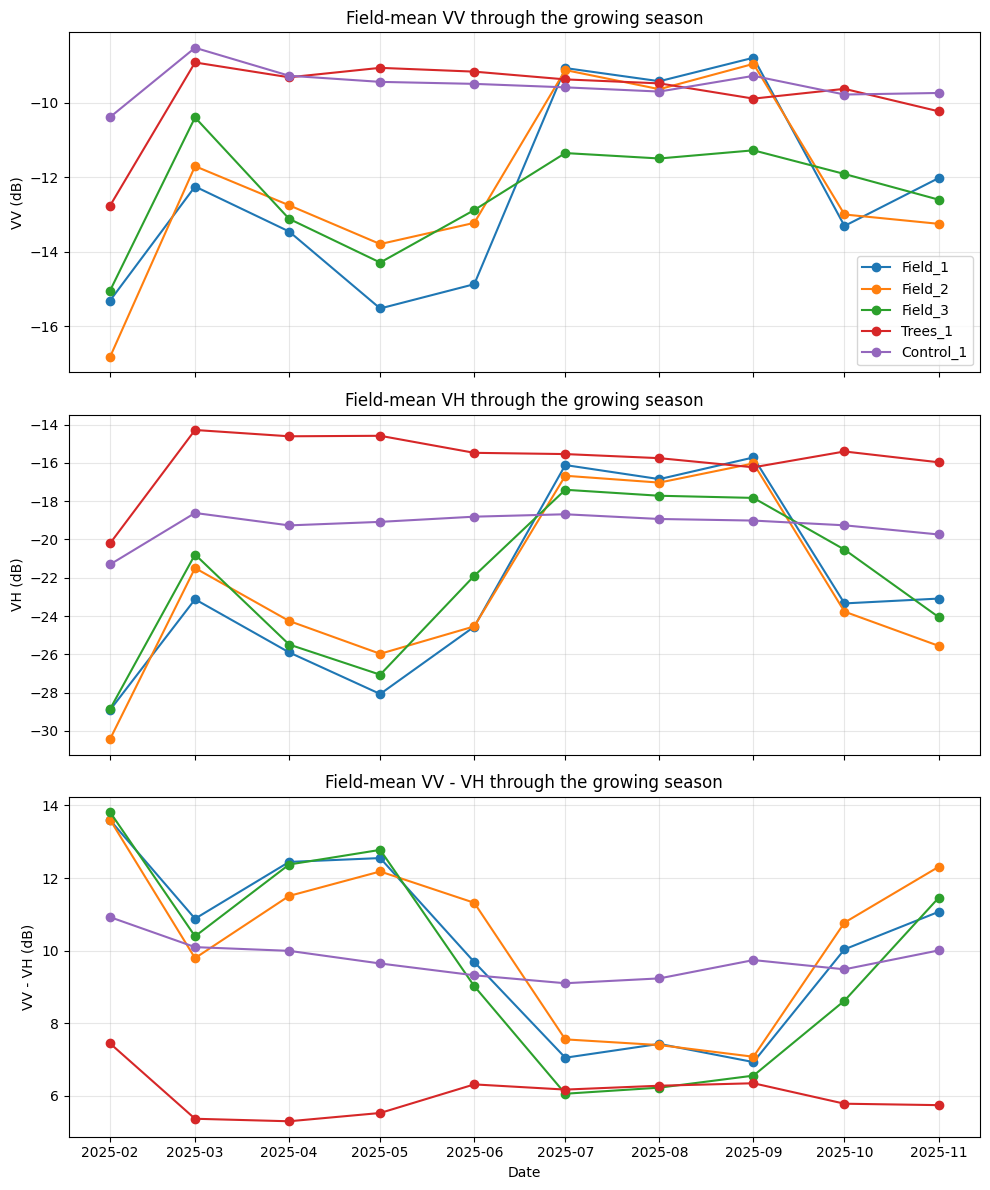

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

for name, df in ts_dict.items():
    axes[0].plot(df["date"], df["VV"], marker="o", label=name)
    axes[1].plot(df["date"], df["VH"], marker="o", label=name)
    axes[2].plot(df["date"], df["VV_minus_VH"], marker="o", label=name)

axes[0].set_title("Field-mean VV through the growing season")
axes[0].set_ylabel("VV (dB)")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Field-mean VH through the growing season")
axes[1].set_ylabel("VH (dB)")
axes[1].grid(True, alpha=0.3)

axes[2].set_title("Field-mean VV - VH through the growing season")
axes[2].set_ylabel("VV - VH (dB)")
axes[2].set_xlabel("Date")
axes[2].grid(True, alpha=0.3)

axes[0].legend()
plt.tight_layout()
plt.show()


## 10. Build a simple crop-growth metric

Next I want you to propose a metric that captures crop development.

Possible first ideas include:

- peak VH minus spring VH,
- July VH minus April VH,
- maximum seasonal VV-VH range,
- cumulative increase from planting to peak growth.

Below is one simple example:

\[
Growth Metric = VH_{peak} - VH_{early}
\]

This is not necessarily the best metric — it is just a starting point.



Summary of all metrics:


,Peak-Early,One-Another,Seasonal_Range,Cumulative_Inc,Sprout_Detector
Field_1,7.409179,9.784995,6.667000,19.120735,3.515821
Field_2,5.464963,7.584866,6.529233,19.235345,1.432247
Field_3,3.381861,8.082974,7.757930,17.729018,5.164333
Trees_1,0.000000,-0.929095,2.144496,6.773156,-0.889576
Control_1,0.000000,0.580706,1.821414,3.268500,0.271115


<Axes: title={'center': 'Crop growth metric'}>

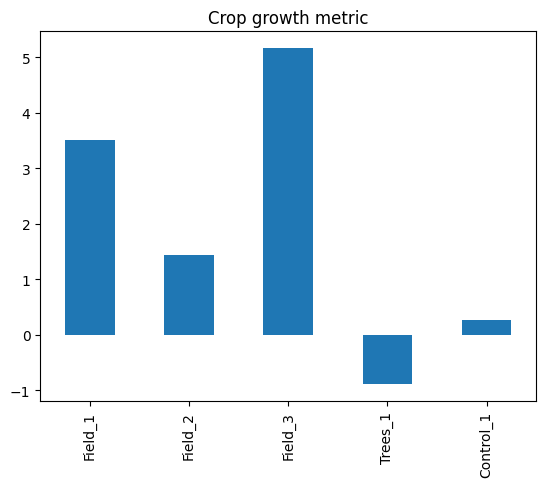

In [27]:
##YOUR CODE HERE (50pts)
def evaluate_metric(ts_dict, metric_func):
    results = {}
    for name, df in ts_dict.items():
        df = df.sort_values("date")

        # define metric
        results[name] = metric_func(df)
        
    # Return as series
    return pd.Series(results, name="Metric_Value")


# peak VH - spring VH
def metric_peak_minus_early(df):
    vh_early = df["VH"].iloc[1] 
    vh_peak = df["VH"].max()
    return vh_peak - vh_early

# VH one month minus another month
def metric_one_vs_another(df):
    df['month'] = pd.to_datetime(df['date']).dt.month
    
    # mean for each month 
    one_vh = df[df['month'] == 4]['VH'].mean()
    another_vh = df[df['month'] == 7]['VH'].mean()
    
    # just for my sanity :))))
    if pd.isna(one_vh) or pd.isna(another_vh):
        return np.nan
        
    return another_vh - one_vh

# max VV-VH minus min VV-VH
def metric_max_range_diff(df):
    return df["VV_minus_VH"].max() - df["VV_minus_VH"].min()

# cumulative growth
def metric_cumulative_growth(df):
    diffs = df["VH"].diff().dropna()
    return diffs[diffs > 0].sum()

# germination detector
def metric_sprout_detector(df):
    df['month'] = pd.to_datetime(df['date']).dt.month
    
    # mean for May and July - when the sprouting happens
    one_vh = df[df['month'] == 5]['VH'].mean()
    two_vh = df[df['month'] == 6]['VH'].mean()
    
    # just for my sanity :))))
    if pd.isna(one_vh) or pd.isna(two_vh):
        return np.nan
        
    return two_vh - one_vh
    
summary = pd.DataFrame({
    "Peak-Early": evaluate_metric(ts_dict, metric_peak_minus_early),
    "One-Another": evaluate_metric(ts_dict, metric_one_vs_another),
    "Seasonal_Range": evaluate_metric(ts_dict, metric_max_range_diff),
    "Cumulative_Inc": evaluate_metric(ts_dict, metric_cumulative_growth),
    "Sprout_Detector": evaluate_metric(ts_dict, metric_sprout_detector),
})

print("Summary of all metrics:")
display(summary)

# Bar plot for selected metric
summary["Sprout_Detector"].plot(kind="bar", title="Crop growth metric")

## 11. Optional: compare fields spatially for one month

It is often useful to look at the mapped field values in the month of strongest contrast.

This can help connect your field-average statistics back to the actual imagery.


In [15]:
img_july = monthly_composite(YEAR, 10, aoi)

m = geemap.Map(center=[43.9, -93.6], zoom=12)
m.addLayer(img_july.select("VV"), vv_vis, "VV July")
m.addLayer(img_july.select("VH"), vh_vis, "VH July")
m.addLayer(img_july.select("VV_minus_VH"), ratio_vis, "VV-VH July")

for name, geom in roi_dict.items():
    m.addLayer(geom, {"color": "yellow"}, name)

m

Map(center=[43.9, -93.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## 12. Optional: identify likely tall vs shorter crops

With Sentinel-1 alone, you should not make an overconfident crop-type classification.  
But you can propose that one field is more consistent with a tall, strongly volume-scattering canopy than another.

For example:
- stronger seasonal VH increase,
- larger mid-season drop in VV-VH,
- more pronounced growth curve.


## Final note
This lab is designed to connect a simple SAR observable to a real seasonal process.  
The goal is not perfect crop classification, but rather to help reason from:

- backscatter,
- polarization,
- time,
- and field geometry

toward a physically grounded interpretation of crop growth.
